<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/KMeans_PhanKhucKhachHang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-MEANS — Phân khúc khách hàng bán lẻ (Customer Segmentation)

Bước 1: Tạo dữ liệu mô phỏng khách hàng

K-MEANS — Phân khúc khách hàng bán lẻ (Customer Segmentation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
n_per_nhom = 40

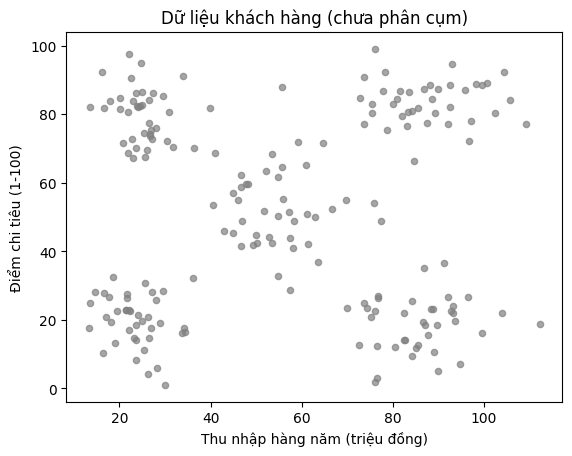

In [2]:
# 5 nhóm khách hàng giả định với đặc điểm thu nhập/chi tiêu khác nhau
nhom = [
    dict(thu_nhap=(25, 6),  chi_tieu=(20, 8)),   # thu nhập thấp, chi tiêu thấp
    dict(thu_nhap=(25, 6),  chi_tieu=(80, 8)),   # thu nhập thấp, chi tiêu cao
    dict(thu_nhap=(85, 10), chi_tieu=(18, 8)),   # thu nhập cao, chi tiêu thấp
    dict(thu_nhap=(88, 10), chi_tieu=(82, 8)),   # thu nhập cao, chi tiêu cao (VIP)
    dict(thu_nhap=(55, 10), chi_tieu=(50, 10)),  # trung bình
]

thu_nhap_list, chi_tieu_list = [], []
for g in nhom:
    thu_nhap_list.append(np.random.normal(g['thu_nhap'][0], g['thu_nhap'][1], n_per_nhom))
    chi_tieu_list.append(np.random.normal(g['chi_tieu'][0], g['chi_tieu'][1], n_per_nhom))

thu_nhap = np.concatenate(thu_nhap_list).clip(10, 150)
chi_tieu = np.concatenate(chi_tieu_list).clip(1, 100)
X = np.column_stack([thu_nhap, chi_tieu])

plt.scatter(X[:,0], X[:,1], s=20, c='gray', alpha=0.7)
plt.xlabel('Thu nhập hàng năm (triệu đồng)'); plt.ylabel('Điểm chi tiêu (1-100)')
plt.title('Dữ liệu khách hàng (chưa phân cụm)')
plt.show()

Bước 2: Chuẩn hóa dữ liệu và chọn số cụm k bằng phương pháp Elbow

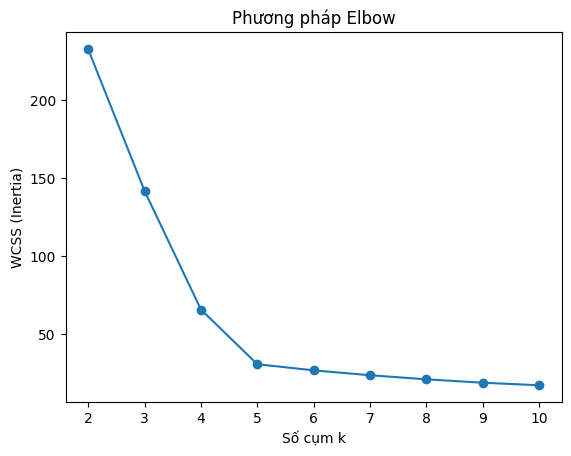

Silhouette score theo k: [(2, np.float64(0.401)), (3, np.float64(0.475)), (4, np.float64(0.593)), (5, np.float64(0.653)), (6, np.float64(0.595)), (7, np.float64(0.543)), (8, np.float64(0.494)), (9, np.float64(0.46)), (10, np.float64(0.448))]


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []      # Within-Cluster Sum of Squares (Inertia)
sil = []       # Silhouette score
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))

plt.plot(list(K_range), wcss, marker='o')
plt.xlabel('Số cụm k'); plt.ylabel('WCSS (Inertia)')
plt.title('Phương pháp Elbow')
plt.show()

print('Silhouette score theo k:', list(zip(K_range, [round(s,3) for s in sil])))

Bước 3: Huấn luyện K-Means với k tối ưu và trực quan hóa

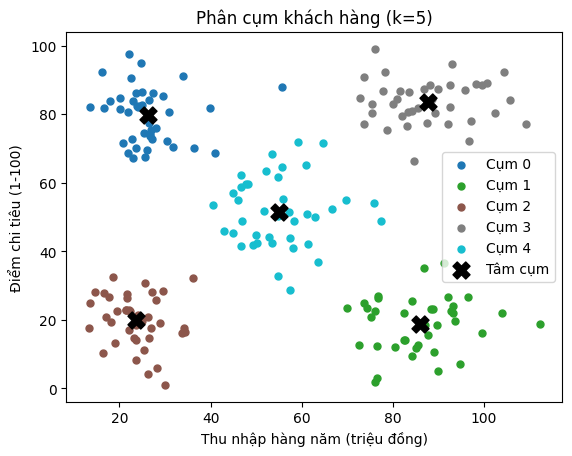

In [4]:
k_toi_uu = 5
km_final = KMeans(n_clusters=k_toi_uu, n_init=10, random_state=42).fit(X_scaled)
labels = km_final.labels_

# Đưa tâm cụm về lại thang đo gốc (chưa chuẩn hóa) để dễ diễn giải
centers = scaler.inverse_transform(km_final.cluster_centers_)

colors = plt.cm.tab10(np.linspace(0, 1, k_toi_uu))
for c in range(k_toi_uu):
    plt.scatter(X[labels==c,0], X[labels==c,1], s=25, color=colors[c], label=f'Cụm {c}')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=150, label='Tâm cụm')
plt.xlabel('Thu nhập hàng năm (triệu đồng)'); plt.ylabel('Điểm chi tiêu (1-100)')
plt.title(f'Phân cụm khách hàng (k={k_toi_uu})')
plt.legend()
plt.show()

Bước 4: Diễn giải ý nghĩa kinh doanh của từng cụm

In [5]:
df = pd.DataFrame({'thu_nhap': thu_nhap, 'chi_tieu': chi_tieu, 'cum': labels})
thong_ke = df.groupby('cum').agg(
    so_luong=('thu_nhap', 'size'),
    tb_thu_nhap=('thu_nhap', 'mean'),
    tb_chi_tieu=('chi_tieu', 'mean'),
).round(1)
print(thong_ke)

     so_luong  tb_thu_nhap  tb_chi_tieu
cum                                    
0          42         26.2         79.7
1          39         85.9         18.8
2          40         23.7         19.8
3          39         87.7         83.6
4          40         55.1         51.6


** Bài tập mở rộng **

Thêm đặc trưng thứ 3 (ví dụ: độ tuổi khách hàng) vào dữ liệu mô phỏng, phân cụm lại với 3 đặc trưng và so sánh silhouette score trước/sau khi thêm chiều.

Thêm đặc trưng độ tuổi vào dữ liệu mô phỏng  

In [6]:
# Giả lập độ tuổi cho 5 nhóm khách hàng
tuoi_1 = np.random.normal(25, 4, n_per_nhom)   # nhóm thu nhập thấp, chi tiêu thấp
tuoi_2 = np.random.normal(28, 4, n_per_nhom)   # nhóm thu nhập thấp, chi tiêu cao
tuoi_3 = np.random.normal(40, 5, n_per_nhom)   # nhóm thu nhập cao, chi tiêu thấp
tuoi_4 = np.random.normal(42, 5, n_per_nhom)   # nhóm thu nhập cao, chi tiêu cao (VIP)
tuoi_5 = np.random.normal(35, 5, n_per_nhom)   # nhóm trung bình

tuoi = np.concatenate([tuoi_1, tuoi_2, tuoi_3, tuoi_4, tuoi_5])

# Ghép thêm vào ma trận X
X3 = np.column_stack([thu_nhap, chi_tieu, tuoi])


Chuẩn hóa dữ liệu và chạy K-Means với 3 đặc trưng

In [7]:
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

km3 = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X3_scaled)
labels3 = km3.labels_

silhouette_3d = silhouette_score(X3_scaled, labels3)
print("Silhouette score với 3 đặc trưng:", silhouette_3d)


Silhouette score với 3 đặc trưng: 0.5054706723263999


So sánh kết quả phân cụm khi dùng init='k-means++' (mặc định, thông minh) và init='random' (khởi tạo hoàn toàn ngẫu nhiên) — chạy nhiều lần với n_init=1 để quan sát độ ổn định của từng cách khởi tạo.

Khởi tạo ngẫu nhiên (init='random')

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dữ liệu đã chuẩn hóa: X_scaled
scores_random = []
for i in range(5):  # chạy nhiều lần để quan sát
    km_rand = KMeans(n_clusters=5, init='random', n_init=1, random_state=None).fit(X_scaled)
    score = silhouette_score(X_scaled, km_rand.labels_)
    scores_random.append(score)
    print(f"Lần {i+1}, silhouette score (random): {score:.3f}")


Lần 1, silhouette score (random): 0.381
Lần 2, silhouette score (random): 0.653
Lần 3, silhouette score (random): 0.653
Lần 4, silhouette score (random): 0.653
Lần 5, silhouette score (random): 0.653


Khởi tạo thông minh (init='k-means++')

In [9]:
scores_plus = []
for i in range(5):  # chạy nhiều lần để quan sát
    km_plus = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=None).fit(X_scaled)
    score = silhouette_score(X_scaled, km_plus.labels_)
    scores_plus.append(score)
    print(f"Lần {i+1}, silhouette score (k-means++): {score:.3f}")


Lần 1, silhouette score (k-means++): 0.653
Lần 2, silhouette score (k-means++): 0.653
Lần 3, silhouette score (k-means++): 0.653
Lần 4, silhouette score (k-means++): 0.653
Lần 5, silhouette score (k-means++): 0.653


Thử ép mô hình chạy với k=2 và k=10 (hai giá trị xa k tối ưu), quan sát và giải thích các cụm bị gộp hoặc bị chia nhỏ không hợp lý như thế nào.

Silhouette score với k=2: 0.401


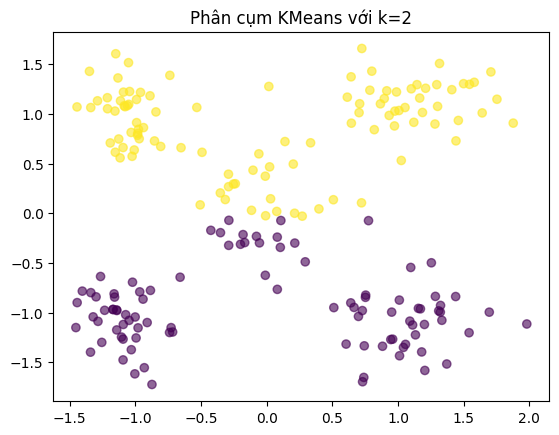

Silhouette score với k=10: 0.448


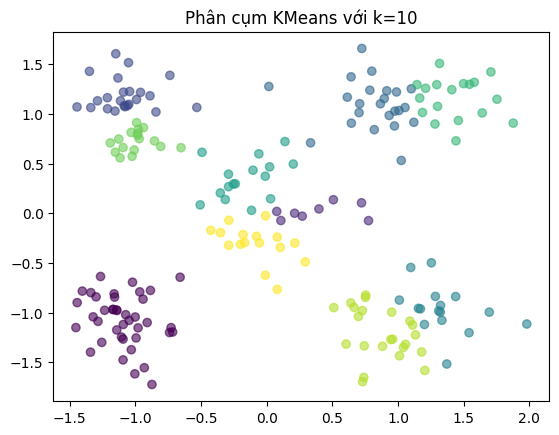

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Dữ liệu đã chuẩn hóa: X_scaled

# Thử với k=2
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_scaled)
labels2 = km2.labels_
score2 = silhouette_score(X_scaled, labels2)
print("Silhouette score với k=2:", round(score2,3))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels2, cmap='viridis', alpha=0.6)
plt.title("Phân cụm KMeans với k=2")
plt.show()

# Thử với k=10
km10 = KMeans(n_clusters=10, n_init=10, random_state=42).fit(X_scaled)
labels10 = km10.labels_
score10 = silhouette_score(X_scaled, labels10)
print("Silhouette score với k=10:", round(score10,3))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels10, cmap='viridis', alpha=0.6)
plt.title("Phân cụm KMeans với k=10")
plt.show()
